# Rice Seedling Detection using MobileNet + SVM

This project implements a hybrid deep learning and machine learning pipeline for detecting rice seedlings from orthomosaic images, inspired by a research paper.

## Import Required Libraries

This section imports all necessary libraries including OpenCV, NumPy, TensorFlow (MobileNet), and Scikit-learn for building the pipeline.

In [97]:
import tensorflow as tf

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 0


In [98]:
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Dataset Loading

The dataset consists of two classes:
- Arable Land (0)
- Rice Seedlings (1)

Images are loaded, resized to 224×224, and labeled accordingly.

In [99]:
import os
import cv2
import numpy as np

def load_dataset(base_path="."):
    images = []
    labels = []

    class_map = {
        "arableland": 0,
        "riceseedling": 1
    }

    for class_name in class_map:
        folder = os.path.join(base_path, class_name)

        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)

            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.resize(img, (224, 224))
            images.append(img)
            labels.append(class_map[class_name])

    return np.array(images), np.array(labels)


# ✅ THIS LINE IS MISSING IN YOUR NOTEBOOK
X, y = load_dataset(".")

print("Dataset loaded:", X.shape)

Dataset loaded: (54628, 224, 224, 3)


In [100]:
print("X shape:", X.shape)
print("y shape:", y.shape)

import numpy as np
print("Class distribution:", np.bincount(y))

X shape: (54628, 224, 224, 3)
y shape: (54628,)
Class distribution: [26581 28047]


## Dataset Subsampling (Paper-Based)

To match the research paper, a subset of 862 samples is selected for training and evaluation.

In [101]:
import numpy as np

# Shuffle first (VERY IMPORTANT)
indices = np.arange(len(X))
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

# Take only 862 samples
X_subset = X[:862]
y_subset = y[:862]

print("Subset shape:", X_subset.shape)
print("Class distribution:", np.bincount(y_subset))

Subset shape: (862, 224, 224, 3)
Class distribution: [422 440]


## Train-Test Split

The dataset is split into:
- Training set: 145 images
- Testing set: 717 images

This follows the same distribution as the paper.

In [102]:
from sklearn.model_selection import train_test_split

# First create train (145)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_subset, y_subset,
    train_size=145,
    stratify=y_subset,
    random_state=42
)

# Remaining goes to test (717)
X_test = X_temp
y_test = y_temp

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (145, 224, 224, 3)
Test: (717, 224, 224, 3)


In [103]:
print(X_train.shape)
print(X_test.shape)

(145, 224, 224, 3)
(717, 224, 224, 3)


In [104]:
import numpy as np

print("Train class distribution:", np.bincount(y_train))

Train class distribution: [71 74]


In [105]:
print("Test class distribution:", np.bincount(y_test))

Test class distribution: [351 366]


## Feature Extraction using MobileNet

MobileNet (pretrained on ImageNet) is used as a feature extractor.
The output feature map is flattened to produce 50176-dimensional feature vectors.

In [106]:
from tensorflow.keras.applications import MobileNet

model = MobileNet(
    weights='imagenet',
    include_top=False  # IMPORTANT
    # ❌ no pooling here
)

print("MobileNet loaded")

/tmp/ipykernel_2048875/3794768413.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = MobileNet(


MobileNet loaded


In [107]:
from tensorflow.keras.applications.mobilenet import preprocess_input

def extract_features(X):
    X = preprocess_input(X.astype('float32'))
    
    features = model.predict(X, verbose=1)  
    features = features.reshape(features.shape[0], -1)  # FLATTEN
    
    return features

In [108]:
print("Extracting train features...")
X_train_feat = extract_features(X_train)

print("Extracting test features...")
X_test_feat = extract_features(X_test)

Extracting train features...
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 462ms/step
Extracting test features...
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step


In [109]:
X_train_feat = extract_features(X_train)
X_test_feat = extract_features(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step


In [110]:
print("Train feature shape:", X_train_feat.shape)
print("Test feature shape:", X_test_feat.shape)

Train feature shape: (145, 50176)
Test feature shape: (717, 50176)


In [111]:
print(X_train_feat.shape)

(145, 50176)


## Feature Scaling

StandardScaler is used to normalize the features before feeding them into the SVM classifier.

In [112]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat = scaler.transform(X_test_feat)

print("Scaling done")

Scaling done


## Classification using SVM

A Linear SVM classifier is trained on extracted features to classify images as rice or non-rice.

In [113]:
from sklearn.svm import LinearSVC

print("Training SVM...")

svm = LinearSVC()   # paper allows kernels
svm.fit(X_train_feat, y_train)

print("SVM trained")

Training SVM...
SVM trained


In [114]:
y_pred = svm.predict(X_test_feat)

print("Prediction done")

Prediction done


In [115]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9679218967921897
Precision: 1.0
Recall: 0.9371584699453552
F1 Score: 0.9675599435825106


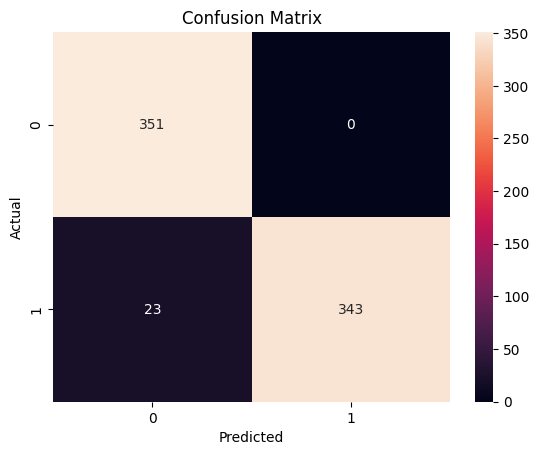

In [116]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Orthomosaic Image Processing

The large orthomosaic image is divided into smaller patches using a sliding window approach.

In [117]:
import cv2

img = cv2.imread("7.tif")  # or .jpg/.png

print("Image shape:", img.shape)

Image shape: (1527, 1527, 3)


In [118]:
def create_patches(image, size=224):
    patches = []
    positions = []

    h, w, _ = image.shape

    for y in range(0, h - size, size):
        for x in range(0, w - size, size):
            patch = image[y:y+size, x:x+size]
            patches.append(patch)
            positions.append((x, y))

    return patches, positions


patches, positions = create_patches(img)

print("Total patches:", len(patches))

Total patches: 36


In [119]:
patches_array = np.array(patches)

patch_features = extract_features(patches_array)

patch_features = scaler.transform(patch_features)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step 


In [120]:
predictions = svm.predict(patch_features)

print("Predictions done")

Predictions done


In [121]:
output = img.copy()

for i, (x, y) in enumerate(positions):
    
    if predictions[i] == 1:  # rice
        
        cv2.rectangle(output, (x, y), (x+224, y+224), (0, 255, 0), 2)

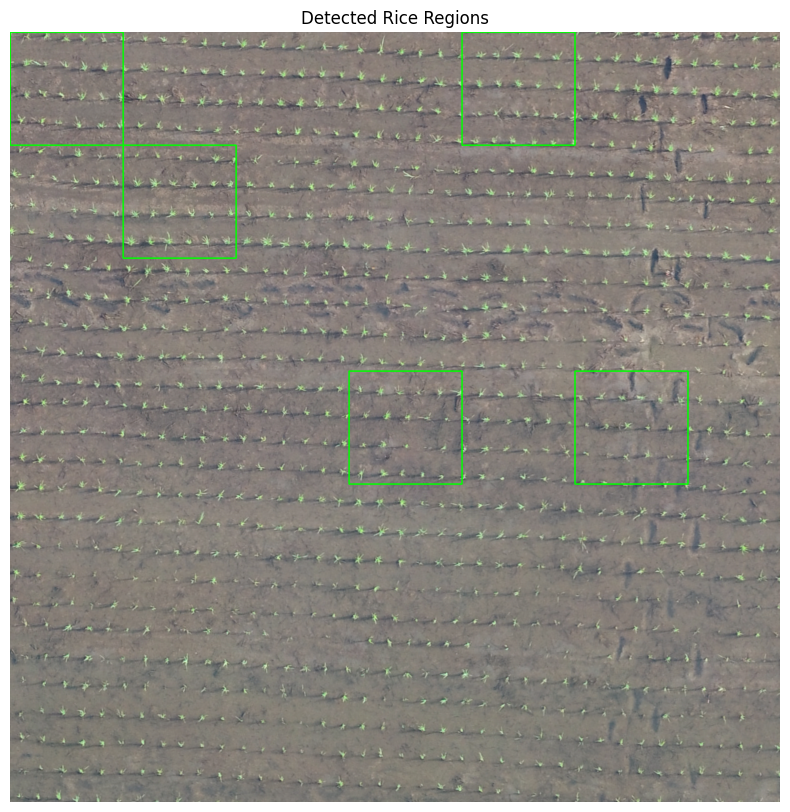

In [122]:
import matplotlib.pyplot as plt
import cv2

# Convert BGR → RGB (VERY IMPORTANT)
output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(output_rgb)
plt.title("Detected Rice Regions")
plt.axis('off')
plt.show()

In [123]:
from sklearn.cluster import KMeans
import numpy as np
import cv2

def apply_kmeans(img, k=2):
    # reshape image → (num_pixels, 3)
    pixel_vals = img.reshape((-1, 3))
    pixel_vals = np.float32(pixel_vals)

    # apply k-means
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(pixel_vals)

    # reshape back to image
    segmented = labels.reshape(img.shape[:2])

    return segmented

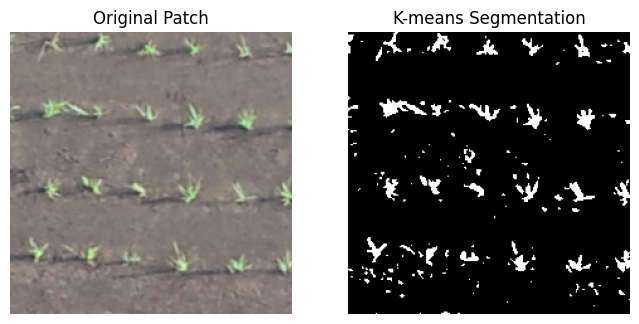

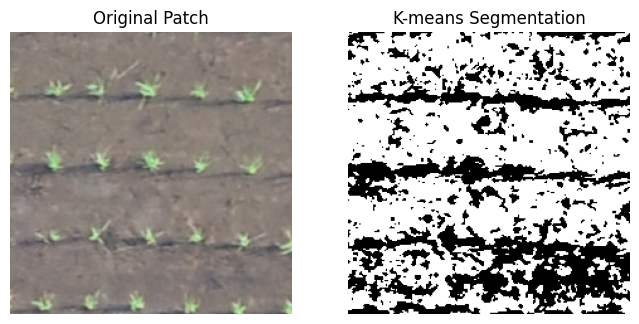

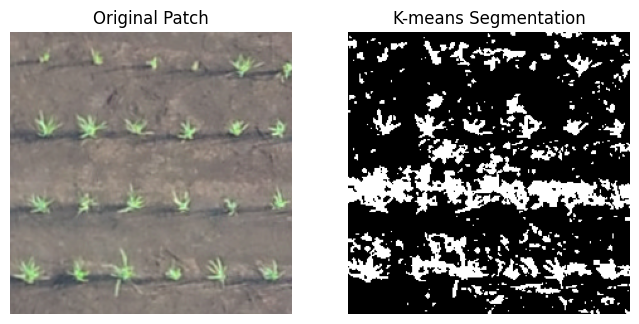

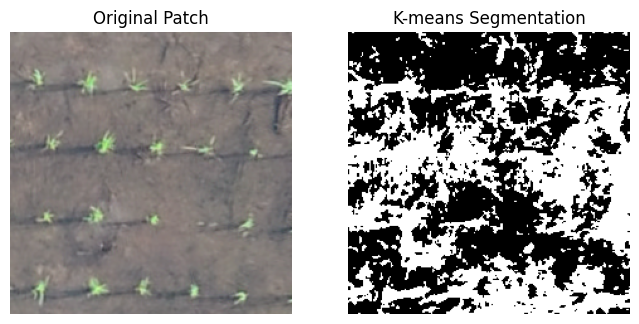

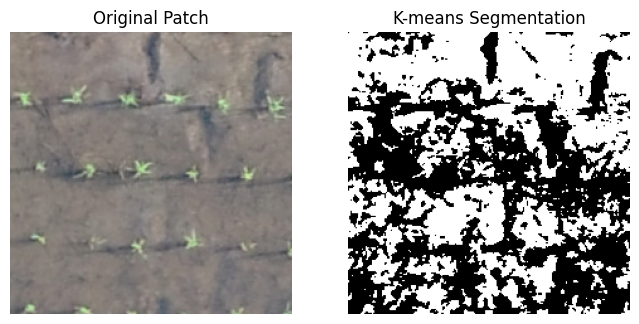

In [124]:
import matplotlib.pyplot as plt

count = 0

for i, (x, y) in enumerate(positions):

    if predictions[i] == 1:   # ONLY rice patches
        
        seg = apply_kmeans(patches[i])

        # convert to RGB for display
        original = cv2.cvtColor(patches[i], cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(8,4))

        # Original
        plt.subplot(1,2,1)
        plt.imshow(original)
        plt.title("Original Patch")
        plt.axis('off')

        # Segmented
        plt.subplot(1,2,2)
        plt.imshow(seg, cmap='gray')
        plt.title("K-means Segmentation")
        plt.axis('off')

        plt.show()

        count += 1
        if count == 5:   # show only first 5
            break

In [125]:
def green_mask(img):
    # Extract channels
    B, G, R = cv2.split(img)

    # Green dominance rule
    mask = (G > R) & (G > B) & (G > 100)

    return mask.astype("uint8") * 255

In [126]:
def improved_segmentation(img):
    
    # Step 1: K-means
    segmented = kmeans_segmentation(img)
    
    # Step 2: Green mask
    g_mask = green_mask(img)
    
    # Step 3: Combine both
    final_mask = cv2.bitwise_and(g_mask, g_mask, mask=segmented.astype("uint8"))
    
    return final_mask

In [127]:
def clean_mask(mask):
    kernel = np.ones((3,3), np.uint8)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask

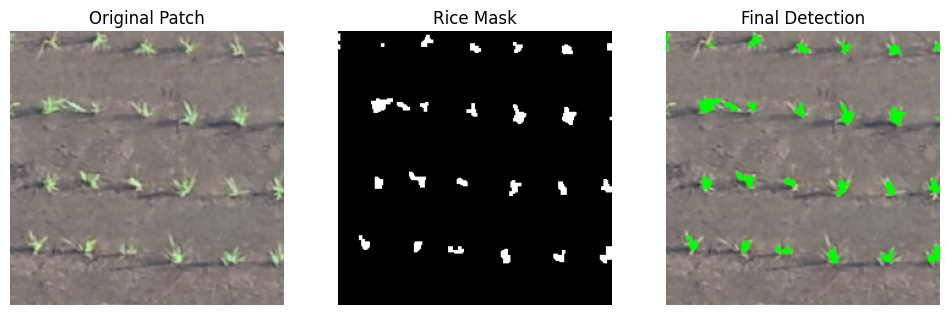

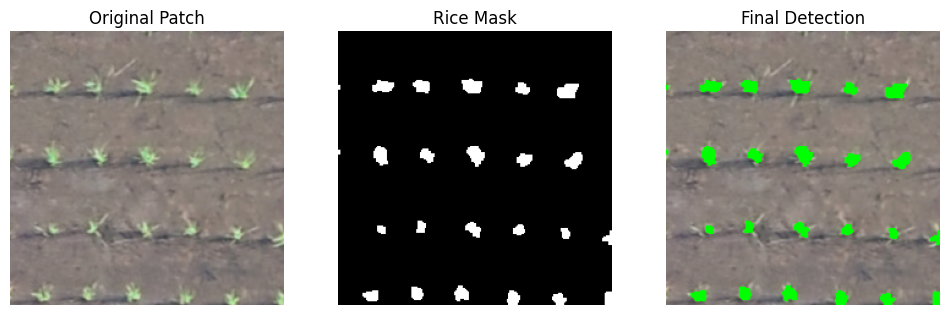

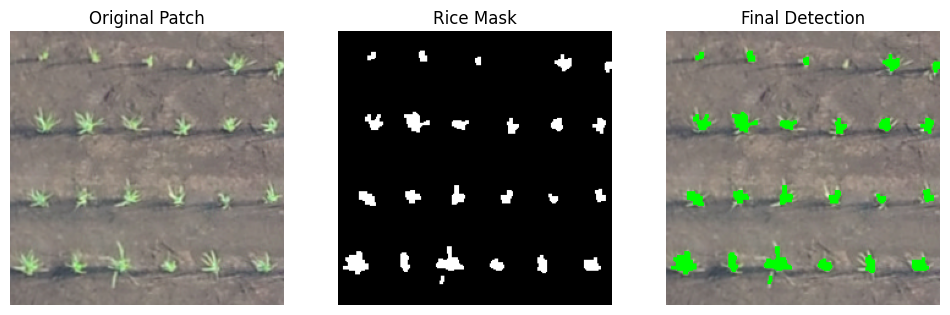

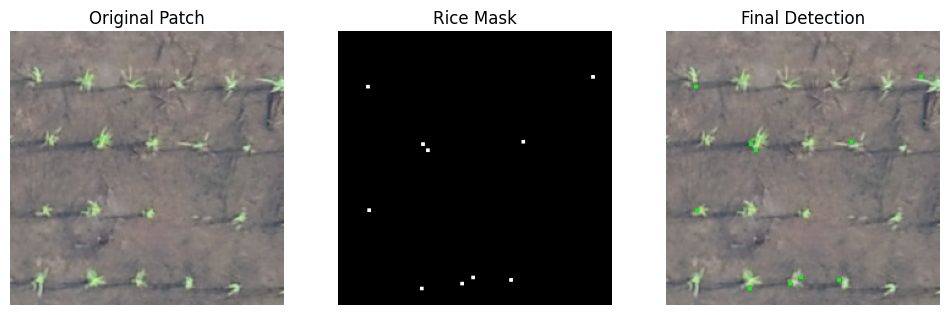

In [128]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# -------- GREEN MASK --------
def green_mask(img):
    B, G, R = cv2.split(img)
    mask = (G > R) & (G > B) & (G > 100)
    return mask.astype("uint8") * 255


# -------- KMEANS --------
def kmeans_segmentation(img):
    pixel_vals = img.reshape((-1, 3))
    pixel_vals = np.float32(pixel_vals)

    kmeans = KMeans(n_clusters=2, random_state=0)
    labels = kmeans.fit_predict(pixel_vals)

    return labels.reshape(img.shape[:2])


# -------- COMBINED --------
def improved_segmentation(img):
    segmented = kmeans_segmentation(img)
    g_mask = green_mask(img)

    final_mask = cv2.bitwise_and(g_mask, g_mask, mask=segmented.astype("uint8"))
    return final_mask


# -------- CLEAN --------
def clean_mask(mask):
    kernel = np.ones((3,3), np.uint8)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask


# -------- VISUALIZATION --------
count = 0

for i, (x, y) in enumerate(positions):

    if predictions[i] == 1:   # only rice patches
        
        patch = patches[i]

        mask = improved_segmentation(patch)
        mask = clean_mask(mask)

        # overlay
        overlay = patch.copy()
        overlay[mask == 255] = [0, 255, 0]

        # convert for display
        patch_rgb = cv2.cvtColor(patch, cv2.COLOR_BGR2RGB)
        overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

        # -------- DISPLAY --------
        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.imshow(patch_rgb)
        plt.title("Original Patch")
        plt.axis('off')

        plt.subplot(1,3,2)
        plt.imshow(mask, cmap='gray')
        plt.title("Rice Mask")
        plt.axis('off')

        plt.subplot(1,3,3)
        plt.imshow(overlay_rgb)
        plt.title("Final Detection")
        plt.axis('off')

        plt.show()

        count += 1
        if count == 4:   # show all detected patches
            break